# 02 - Modelo baseline

Este notebook construye una primera referencia con regresión logística para tener una línea base interpretable antes de comparar modelos más flexibles.

In [12]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

## Datos y objetivo

Se carga el dataset y se crea `Target_bin`, manteniendo el mismo criterio de abandono definido en el EDA.

In [14]:
df = pd.read_csv("../data/dataset.csv")
df["Target_bin"] = (df["Target"] == "Dropout").astype(int)

## Selección de variables y partición

Se separan predictores y objetivo, se excluyen columnas no disponibles o directamente ligadas al target, y se crea una partición estratificada de entrenamiento y test.

In [15]:
drop_cols = [
    "Target", "Target_bin",
    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)"
]

X = df.drop(columns=drop_cols)
y = df["Target_bin"]

In [16]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

print("NumÃƒÂ©ricas:", numeric_features)
print("CategÃƒÂ³ricas:", categorical_features)

NumÃƒÂ©ricas: ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']
CategÃƒÂ³ricas: []


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(3539, 28) (885, 28)
0.3212771969482905 0.32090395480225986


## Preprocesado y pipeline

El pipeline combina imputación, escalado y codificación one-hot. Encapsularlo evita fugas de información entre entrenamiento y evaluación.

In [18]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## Entrenamiento del baseline

La regresión logística sirve como referencia inicial: es rápida, estable y facilita interpretar si los modelos posteriores aportan mejora real.

In [19]:
baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

In [20]:
baseline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## Evaluación en test

Se calculan métricas globales, matriz de confusión y reporte de clasificación. En este problema son especialmente importantes `recall` y falsos negativos, porque no detectar abandono tiene coste práctico.

In [21]:
y_pred = baseline.predict(X_test)
y_proba = baseline.predict_proba(X_test)[:, 1]

In [22]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Accuracy: 0.8564971751412429
Precision: 0.8488888888888889
Recall: 0.6725352112676056
F1: 0.75049115913556
ROC-AUC: 0.9087787959035409


In [23]:
print(classification_report(y_test, y_pred, target_names=["No Dropout", "Dropout"]))

              precision    recall  f1-score   support

  No Dropout       0.86      0.94      0.90       601
     Dropout       0.85      0.67      0.75       284

    accuracy                           0.86       885
   macro avg       0.85      0.81      0.82       885
weighted avg       0.86      0.86      0.85       885



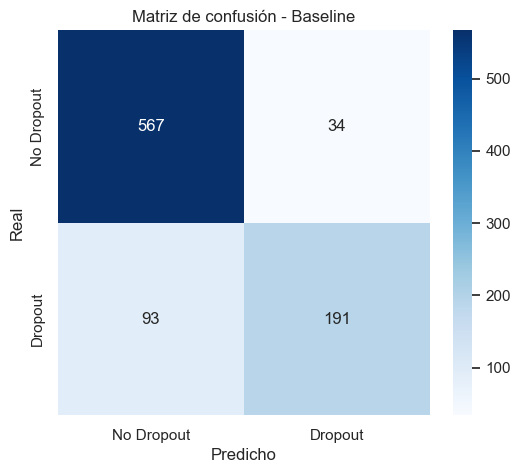

In [24]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Dropout", "Dropout"],
            yticklabels=["No Dropout", "Dropout"])
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de confusiÃƒÂ³n - Baseline")
plt.show()

## Validación cruzada

La validación cruzada estima la estabilidad del baseline en entrenamiento y da una referencia más robusta que una única partición.

In [25]:
cv_results = cross_validate(
    baseline,
    X_train, y_train,
    cv=5,
    scoring=["f1", "recall", "precision", "roc_auc"]
)

for metric in cv_results:
    if metric.startswith("test_"):
        print(metric, cv_results[metric].mean(), "Ã‚Â±", cv_results[metric].std())

test_f1 0.7422556835649546 Ã‚Â± 0.024948541921997098
test_recall 0.6736803462400495 Ã‚Â± 0.024472186576068016
test_precision 0.8269178723933228 Ã‚Â± 0.032545424114961446
test_roc_auc 0.8973239289212074 Ã‚Â± 0.012138133363810883
